In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# Why will a fluorocarbon not dissolve in anything? (Figure 11.2-3)

This notebook draws **Figure 11.2-3** — the liquid-liquid coexistence curves of
perfluoro-*n*-heptane with five ordinary solvents — from the measurements themselves,
and then asks whether the chapter's own theory can explain them.

**The data are from the paper, not from the picture.** J. H. Hildebrand, B. B. Fisher and
H. A. Benesi, *Solubility of Perfluoro-n-heptane in Benzene and Other Solvents*,
**J. Am. Chem. Soc. 72**, 4348 (1950), Table I: forty-five measured consolute
temperatures across five binaries, each reported at both a volume fraction and a mole
fraction, which is what the figure's two panels are.

**Why fluorocarbons are the interesting case.** Perfluoroheptane and *n*-heptane are the
same molecule with fluorine in place of hydrogen. Both are nonpolar, neither associates,
and by every rule of thumb they ought to mix freely. They do not: the mixture separates
into two liquids below 50 °C. Fluorocarbons are so reluctant to mix with anything that
this is the basis of fluorous-phase chemistry, of non-stick surfaces, and of blood
substitutes — a liquid that dissolves oxygen well and dissolves in nothing.

**And the chapter's theory gets it half right, which is more instructive than getting
it right.** Regular solution theory predicts the critical *composition* of all five
mixtures to better than 0.02 in mole fraction, and the critical *temperature* wrong by up
to 250 K. The last section runs that down.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026


In [2]:
import sys; sys.path.append("..")
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants
from scipy.interpolate import CubicSpline

from thermo.activity_models import RegularSolution
from thermo.charts import use_book_style
from thermo import lle

use_book_style()
R = constants.R
CAL = 4.184                      # J per calorie, for (cal/ml)^1/2 -> Pa^1/2

# Hildebrand, Fisher and Benesi, J. Am. Chem. Soc. 72, 4348 (1950), Table I.
# Species 1 is perfluoro-n-heptane; species 2 is the solvent. phi2 is the volume
# fraction (reported at 25 C), x2 the mole fraction, t the consolute temperature in C.
#
# Transcribed from the paper. The n-heptane entry at phi2 = 0.151 is printed on a
# degraded 1950 scan and reads 27.3 or 27.8; 27.3 is used, and at the scale of the
# figure the difference is invisible. Nothing else was ambiguous.
TABLE_I = {
    "C$_6$H$_6$": ([0.100, 0.193, 0.300, 0.425, 0.501, 0.618, 0.655, 0.707, 0.800, 0.900],
                   [0.220, 0.374, 0.518, 0.650, 0.717, 0.802, 0.827, 0.859, 0.910, 0.958],
                   [56.6, 85.8, 102.1, 109.9, 113.1, 113.4, 113.3, 112.5, 107.6, 92.2]),
    "CHCl$_3$":   ([0.089, 0.197, 0.300, 0.407, 0.505, 0.611, 0.704, 0.796, 0.905],
                   [0.224, 0.405, 0.545, 0.642, 0.740, 0.814, 0.872, 0.915, 0.964],
                   [24.6, 55.8, 69.9, 75.7, 78.2, 78.4, 77.3, 72.8, 55.8]),
    "CCl$_4$":    ([0.097, 0.187, 0.300, 0.396, 0.495, 0.603, 0.708, 0.800, 0.900],
                   [0.199, 0.348, 0.499, 0.604, 0.687, 0.779, 0.850, 0.903, 0.954],
                   [2.8, 32.3, 49.1, 55.9, 58.4, 58.7, 57.6, 53.3, 33.4]),
    "C$_7$H$_{16}$": ([0.151, 0.211, 0.303, 0.366, 0.400, 0.505, 0.609, 0.706, 0.809, 0.907],
                      [0.214, 0.291, 0.400, 0.469, 0.504, 0.609, 0.707, 0.787, 0.865, 0.938],
                      [27.3, 36.5, 45.8, 48.5, 49.3, 50.0, 49.9, 48.5, 42.1, 24.0]),
    "C$_8$H$_{18}$": ([0.205, 0.315, 0.398, 0.516, 0.614, 0.715, 0.810],
                      [0.255, 0.377, 0.467, 0.584, 0.677, 0.768, 0.845],
                      [10.6, 19.8, 22.8, 23.7, 23.6, 22.2, 16.9]),
}

print(f"  {sum(len(v[2]) for v in TABLE_I.values())} measured consolute temperatures, "
      f"{len(TABLE_I)} binaries")

  45 measured consolute temperatures, 5 binaries



## First, does the table survive transcription?

**This table checks itself, and that is the reason to transcribe both of its
composition columns rather than only the one you plan to plot.** Volume fraction and mole
fraction are not independent — they are related through the molar volumes,

$$\phi_2 = \frac{x_2 v_2}{x_2v_2 + x_1v_1}
\qquad\Longrightarrow\qquad
\frac{v_2}{v_1} = \frac{\phi_2\,(1-x_2)}{x_2\,(1-\phi_2)}$$

so **every one of the forty-five points independently estimates the same ratio** for its
solvent. A digit lost in transcription shows up immediately as one point disagreeing with
its neighbors, and nothing external is needed to see it.

Better still, the ratios can be turned into an absolute number. Divide the solvent's
known molar volume by the ratio and you get the molar volume of perfluoro-*n*-heptane —
five times over, from five different solvents, none of which the paper used for that
purpose.


In [3]:
# solvent molar volumes at 25 C, ml/mol, from the pure component densities
V2_LIT = {"C$_6$H$_6$": 89.4, "CHCl$_3$": 80.7, "CCl$_4$": 97.1,
          "C$_7$H$_{16}$": 147.5, "C$_8$H$_{18}$": 166.1}

print(f"  {'solvent':16s} {'v2/v1 mean':>11s} {'spread':>8s} {'implied v1':>12s}   outliers")
for name, (phi2, x2, t) in TABLE_I.items():
    phi2, x2 = np.array(phi2), np.array(x2)
    r = phi2 * (1 - x2) / (x2 * (1 - phi2))
    dev = np.abs(r - np.median(r)) / np.median(r)
    bad = [f"phi2={p:.3f}" for p, d in zip(phi2, dev) if d > 0.03]
    print(f"  {name:16s} {r.mean():11.4f} {r.max() - r.min():8.4f} "
          f"{V2_LIT[name] / r.mean():9.1f} ml   {', '.join(bad) if bad else '-'}")

print("\n  Hildebrand's own Table II gives the molar volume of perfluoro-n-heptane")
print("  as 225 ml/mol at 23.7 C.")

  solvent           v2/v1 mean   spread   implied v1   outliers
  C$_6$H$_6$            0.3970   0.0064     225.2 ml   -
  CHCl$_3$              0.3582   0.0443     225.3 ml   phi2=0.089, phi2=0.407
  CCl$_4$               0.4325   0.0187     224.5 ml   phi2=0.495
  C$_7$H$_{16}$         0.6523   0.0164     226.1 ml   -
  C$_8$H$_{18}$         0.7609   0.0286     218.3 ml   phi2=0.810

  Hildebrand's own Table II gives the molar volume of perfluoro-n-heptane
  as 225 ml/mol at 23.7 C.



Four of the five solvents put perfluoro-*n*-heptane between 224 and 226 ml/mol against
the paper's own 225 — an agreement the transcription had to earn, since a single wrong
digit anywhere would have broken it.

**Three points fail the identity by more than rounding can explain**, and re-reading
them at high resolution off the original page shows the transcription is right: the
inconsistency is the paper's. These are 1950 hand computations, and the figure plots the
numbers as published rather than as corrected.

## The figure

Both panels of Figure 11.2-3, which are Hildebrand's own Figures 1 and 2: the
same five coexistence curves against mole fraction and against volume fraction. The point
of showing both is the shape — plotted against volume fraction the curves are far more
symmetric, because volume fraction is the composition variable the underlying theory is
actually written in.


label collisions: none
wrote pdf/Figure_11.2-3.pdf


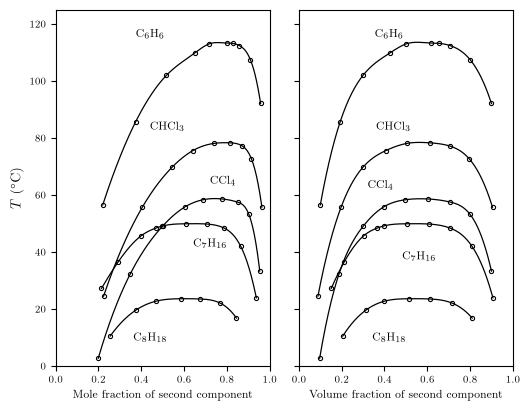

In [4]:

# --- Print art: Figure 11.2-3 ----------------------------------------------
#   pdf/Figure_11.2-3.pdf -> deliverables/figures/print-bw/ch11/c11f006.pdf
#
# REDRAWN FROM THE PRIMARY DATA, replacing a third-party reprint. The book prints
# this figure "Reprinted with permission from ... the American Chemical Society"; it
# is Hildebrand's Table I, so it can be drawn rather than borrowed, and the caption
# becomes a data credit instead of a reprint permission.
#
# Pure black ink: open circles for the measurements, a thin spline through each set,
# and the solvent named beside its own curve. Nothing is separated by tint or color.
# Taller than it is wide per panel, as the printed art is. At 3.3 in the curves are
# only about 10 K apart on the page and an 8 pt label does not fit between them --
# the label-on-curve test below fails on CCl4 and CHCl3 at that height.
fig, axes = plt.subplots(1, 2, figsize=(5.4, 4.2), sharey=True)

# where to put each solvent's label: (panel-0 x, y), (panel-1 x, y)
LABELS = {
    "C$_6$H$_6$":    ((0.44, 116.5), (0.42, 116.5)),
    "CHCl$_3$":      ((0.52,  84.0), (0.44,  84.0)),
    "CCl$_4$":       ((0.78,  65.0), (0.38,  63.5)),
    "C$_7$H$_{16}$": ((0.72,  43.0), (0.56,  38.5)),
    "C$_8$H$_{18}$": ((0.44,  10.0), (0.42,  10.0)),
}

# `col` selects the DATA column (1 = mole fraction, 0 = volume fraction) and
# `panel` selects the axes; they are deliberately not the same index, and using one
# for the other silently swaps every label between the two panels.
for panel, (ax, col, xlabel) in enumerate(
        ((axes[0], 1, "Mole fraction of second component"),
         (axes[1], 0, "Volume fraction of second component"))):
    for name, cols in TABLE_I.items():
        c = np.array(cols[col], dtype=float)
        t = np.array(cols[2], dtype=float)
        ax.plot(c, t, "o", color="k", ms=3.0, mfc="none", mew=0.8)
        smooth = CubicSpline(c, t)
        grid = np.linspace(c.min(), c.max(), 300)
        ax.plot(grid, smooth(grid), "-", color="k", lw=0.9)
        lx, ly = LABELS[name][panel]
        ax.text(lx, ly, name, fontsize=8, ha="center", va="center")
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 125)
    ax.set_xticks(np.arange(0, 1.01, 0.2))
    ax.set_yticks(np.arange(0, 121, 20))
    ax.tick_params(labelsize=7)

axes[0].set_ylabel(r"$T$ ($^\circ$C)")

fig.canvas.draw()
rend = fig.canvas.get_renderer()

# Two collision tests, not one. Label-against-label is the obvious check and it
# passes even when a label is sitting on top of a curve, which is the failure that
# actually happens on a five-curve figure. The second test walks each drawn line in
# display coordinates and asks whether it enters any label's box.
trouble = []
for ax in axes:
    boxes = [(t.get_text(), t.get_window_extent(renderer=rend)) for t in ax.texts]
    trouble += [f"{p} / {q}" for i, (p, bp) in enumerate(boxes)
                for q, bq in boxes[i + 1:] if bp.overlaps(bq)]
    for name, box in boxes:
        pad = box.expanded(1.15, 1.25)          # a little air around the type
        for line in ax.lines:
            xy = ax.transData.transform(line.get_xydata())
            if any(pad.contains(px, py) for px, py in xy):
                trouble.append(f"{name} sits on a curve")
                break
print("label collisions:", "; ".join(sorted(set(trouble))) if trouble else "none")
assert not trouble, "move a label before staging this art"

os.makedirs("pdf", exist_ok=True)
fig.tight_layout()
fig.savefig("pdf/Figure_11.2-3.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Figure_11.2-3.pdf")


## Now the physics: can Section 11.2's theory produce these curves?

Perfluoroheptane with a hydrocarbon is the textbook case for **regular solution theory**
— both species nonpolar, neither associating, no hydrogen bonding, no charge transfer.
Section 11.2 and Problem 11.2-1 give the closed forms for its critical point,

$$x_1^c = \frac{\sqrt{v_1^2 + v_2^2 - v_1v_2}\;-\;v_1}{v_2 - v_1},
\qquad
RT_c = \frac{2x_1^cx_2^c\,v_1^2v_2^2}{(x_1^cv_1 + x_2^cv_2)^3}\,(\delta_1-\delta_2)^2$$

and Hildebrand's Table II hands us everything they need: the molar volumes and solubility
parameters of both species at each measured critical point.

Two predictions, then, and they are scored separately below.


In [5]:
# Hildebrand Table II: solvent, t_c (C), phi2 at the critical point, v2, v1 (ml/mol),
# delta2, delta1 ((cal/ml)^1/2), all at the critical temperature of that mixture.
TABLE_II = [("C$_8$H$_{18}$",  23.7, 0.550, 165.8, 225, 6.88, 5.87),
            ("C$_7$H$_{16}$",  50.0, 0.540, 152.3, 235, 7.13, 5.55),
            ("CCl$_4$",        58.7, 0.578, 101.3, 239, 8.13, 5.45),
            ("CHCl$_3$",       78.5, 0.578,  86.9, 248, 8.42, 5.20),
            ("C$_6$H$_6$",    113.5, 0.594, 100.7, 268, 7.84, 4.73)]

print(f"  {'solvent':16s} {'x1c meas':>9s} {'x1c calc':>9s} | {'Tc meas':>8s} "
      f"{'Tc calc':>8s} {'error':>8s}")
for name, tc, phi2c, v2, v1, d2, d1 in TABLE_II:
    x1c = (np.sqrt(v1**2 + v2**2 - v1 * v2) - v1) / (v2 - v1)
    dd = (d1 - d2) * np.sqrt(CAL * 1e6)                       # Pa^(1/2)
    V1, V2 = v1 * 1e-6, v2 * 1e-6                             # m^3/mol
    Tc = (2 * x1c * (1 - x1c) * V1**2 * V2**2
          / (x1c * V1 + (1 - x1c) * V2)**3 * dd**2 / R)
    x1_meas = ((1 - phi2c) / v1) / ((1 - phi2c) / v1 + phi2c / v2)
    print(f"  {name:16s} {x1_meas:9.3f} {x1c:9.3f} | {tc + 273.15:8.1f} {Tc:8.1f} "
          f"{Tc - (tc + 273.15):+8.1f} K")

  solvent           x1c meas  x1c calc |  Tc meas  Tc calc    error
  C$_8$H$_{18}$        0.376     0.388 |    296.8     50.4   -246.4 K
  C$_7$H$_{16}$        0.356     0.345 |    323.1    123.0   -200.2 K
  CCl$_4$              0.236     0.227 |    331.8    319.2    -12.7 K
  CHCl$_3$             0.204     0.186 |    351.6    459.8   +108.1 K
  C$_6$H$_6$           0.204     0.200 |    386.6    469.8    +83.1 K



**The critical composition is right every time** — within 0.018 in mole fraction across
five mixtures whose critical compositions range from 0.20 to 0.38. That is not luck: it
follows from the molar volumes alone, and the theory gets the *size* asymmetry right.

**The critical temperature is wrong by up to 250 K**, and not even consistently in one
direction: too low for the two hydrocarbons, too high for chloroform and benzene. A
prediction that is off by a factor of six for isooctane cannot be rescued by tuning.

## Reading the failure the way the paper does

Hildebrand's own move is to invert the question: instead of predicting $T_c$ from
$\delta_1 - \delta_2$, ask **what $\delta_1 - \delta_2$ the observed $T_c$ requires** and
compare it with the measured one. Table II's last columns are exactly that, and
reproducing them is a check on this notebook and on the module.


In [6]:
print(f"  {'solvent':16s} {'d2-d1 measured':>15s} {'required by Tc':>15s} "
      f"{'paper, Eq. 5':>13s}")
paper_eq5 = {"C$_8$H$_{18}$": 2.47, "C$_7$H$_{16}$": 2.58, "CCl$_4$": 2.78,
             "CHCl$_3$": 2.90, "C$_6$H$_6$": 2.89}
for name, tc, phi2c, v2, v1, d2, d1 in TABLE_II:
    x1c = (np.sqrt(v1**2 + v2**2 - v1 * v2) - v1) / (v2 - v1)
    V1, V2 = v1 * 1e-6, v2 * 1e-6
    pre = 2 * x1c * (1 - x1c) * V1**2 * V2**2 / (x1c * V1 + (1 - x1c) * V2)**3 / R
    dd_needed = np.sqrt((tc + 273.15) / pre) / np.sqrt(CAL * 1e6)
    print(f"  {name:16s} {d2 - d1:15.2f} {dd_needed:15.2f} {paper_eq5[name]:13.2f}")

  solvent           d2-d1 measured  required by Tc  paper, Eq. 5
  C$_8$H$_{18}$               1.01            2.45          2.47
  C$_7$H$_{16}$               1.58            2.56          2.58
  CCl$_4$                     2.68            2.73          2.78
  CHCl$_3$                    3.22            2.82          2.90
  C$_6$H$_6$                  3.11            2.82          2.89



The middle column reproduces the paper's own to about 2 %, so the theory is being applied
the way its authors applied it. And the comparison it makes is stark: **every one of these
mixtures behaves as though the two species differed in solubility parameter by about
2.5–2.9, when they actually differ by 1.0–3.2, and the discrepancy is largest exactly
where the two liquids are most alike.**

Isooctane and perfluoroheptane differ by 1.01 in solubility parameter and phase-separate
as though they differed by 2.47. They are the most similar pair in the table by that
measure, and they are the most spectacular failure.

**What breaks is the geometric mean.** Regular solution theory assumes the
attraction between unlike molecules is the geometric mean of the two like attractions,
$c_{12} = \sqrt{c_{11}c_{22}}$, which is what makes $\delta_1 - \delta_2$ the only thing
that matters. For fluorocarbon + hydrocarbon that assumption fails badly: fluorine's
electrons are held so tightly that a C–F group is far less polarizable than its size
suggests, so it attracts a hydrocarbon much less than the geometric mean predicts. The
mixture is therefore *more* nonideal than any pair of $\delta$'s can express, and it
separates at temperatures the theory says it should not.

This is the honest version of the lesson Section 11.2 draws from Figure 11.2-3, and it
is why the section moves on to models with fitted parameters. It is also why the same
figure is kept: it is the clearest case in the book of a theory failing for a
reason you can name.

## Your turn

1. The $\delta$'s in Table II are quoted at each mixture's own critical temperature.
   Solubility parameters fall with temperature — check how much of the disagreement above
   could be absorbed by evaluating all five at 25 °C instead.
2. Fit a one-constant Margules $A$ to each measured $T_c$ using $T_{uc} = A/2R$, then
   compare the five $A$ values with $v(\delta_1-\delta_2)^2$. What does the ratio tell
   you about the geometric-mean assumption?
3. Regular solution theory can be repaired for this system with one extra parameter,
   $c_{12} = (1 - \ell_{12})\sqrt{c_{11}c_{22}}$. Find the $\ell_{12}$ each mixture needs.
   Is it the same for all five — that is, is it a property of the fluorocarbon?
4. Plot the coexistence curve `lle.binary_lle_envelope` gives for the isooctane mixture
   with the Table II parameters, and put the measurements on top. Where does the shape go
   wrong, and is it the same place the temperature does?
5. The volume-fraction panel is visibly more symmetric than the mole-fraction one. Show
   why by writing the regular solution $G^{\rm ex}$ in each variable.
6. Perfluoroheptane dissolves oxygen roughly twenty times better than water does, which is
   what makes fluorocarbon blood substitutes possible. Using Section 11.1's machinery and
   Table 11.1-1, estimate the solubility of O₂ in perfluoroheptane at 1 atm and compare
   with water.
